In [2]:
# === paths ===
import sys, os, platform

BASE = os.getcwd()  # ResultAnalyzer.ipynb があるディレクトリ
AN_DIR = os.path.join(BASE, "Analyzer")
if AN_DIR not in sys.path:
    sys.path.insert(0, AN_DIR)

print("Python:", platform.python_version())
print("CWD   :", BASE)
print("AN_DIR:", AN_DIR)

# 存在チェック
assert os.path.exists(os.path.join(AN_DIR, "analyzer.py")), "Analyzer/analyzer.py が見つかりません"
assert os.path.exists(os.path.join(AN_DIR, "dataset.py")),  "Analyzer/dataset.py が見つかりません"
assert os.path.exists(os.path.join(BASE, "SurvayResult.csv")), "SurvayResult.csv が見つかりません"


Python: 3.11.5
CWD   : C:\Users\tenma\Desktop\KeioSchool\InteractiveSmartHome\InteractiveSmartHome\Experiment\Results
AN_DIR: C:\Users\tenma\Desktop\KeioSchool\InteractiveSmartHome\InteractiveSmartHome\Experiment\Results\Analyzer


In [3]:
import pandas as pd
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

from analyzer import SurveyResultAnalyzer  # Analyzer/analyzer.py


In [38]:
CSV_PATH = os.path.join(BASE, "./ResultData/SurvayResult.csv")
df = pd.read_csv(CSV_PATH, header=0)
print("shape:", df.shape)

analyzer = SurveyResultAnalyzer(df)


shape: (96, 44)


In [15]:
long_df = analyzer.to_long_scores()
display(long_df.head(12))

print("Scales:", sorted(long_df["Scale"].unique()))
print("TAM subscales:", sorted(long_df[long_df["Scale"]=="TAM"]["Subscale"].unique()))


,Condition,Scale,Subscale,Score
0,SpatialReference,SUS,Total,45.000
1,SpatialReference,TPA,Total,4.167
2,SpatialReference,TAM,PEOU,2.833
3,SpatialReference,TAM,PU,3.667
4,SpatialReference,TAM,Total,3.250
5,SpatialReference,NASA-TLX,Mental,13.000
6,SpatialReference,NASA-TLX,Physical,15.000
7,SpatialReference,NASA-TLX,Temporal,10.000
8,SpatialReference,NASA-TLX,Performance,7.000
9,SpatialReference,NASA-TLX,Effort,16.000


Scales: ['NASA-TLX', 'SUS', 'TAM', 'TPA']
TAM subscales: ['PEOU', 'PU', 'Total']


In [16]:
from pandas import DataFrame

def dict2df(d):  # ネストdict→DataFrame
    return DataFrame(d).T

sus_desc = analyzer.describe_sus(with_ci=True)            # 中央値/IQR/95%CI まで出る想定
tpa_desc = analyzer.describe_tpa(with_ci=True)
tam_desc = analyzer.describe_tam(with_ci=True)
tlx_desc = analyzer.describe_nasa_tlx(with_ci=True)

print("=== SUS ===");    display(dict2df(sus_desc))
print("=== TPA ===");    display(dict2df(tpa_desc))

print("=== TAM (PEOU/PU/Total) ===")
tmp = {}
for cond, subdict in tam_desc.items():
    for sub, stats in subdict.items():
        tmp[(cond, sub)] = stats
display(DataFrame(tmp).T)

print("=== NASA-TLX (各次元+Overall) ===")
tmp = {}
for cond, subdict in tlx_desc.items():
    for sub, stats in subdict.items():
        tmp[(cond, sub)] = stats
display(DataFrame(tmp).T)


=== SUS ===


,mean,std,median,iqr,n,ci95
SpatialReference,50.938,13.610,52.500,18.125,24,"(45.0, 60.0)"
SpatialReference+Pointing,80.521,14.577,83.750,17.500,24,"(75.0, 87.5)"
Pointing,78.333,13.627,76.250,18.750,24,"(70.0, 87.5)"
Label,47.917,16.806,42.500,25.625,24,"(40.0, 60.0)"


=== TPA ===


,mean,std,median,iqr,n,ci95
SpatialReference,4.299,1.182,4.083,1.812,24,"(3.625, 5.166666666666667)"
SpatialReference+Pointing,6.024,0.697,6.042,0.854,24,"(5.75, 6.25)"
Pointing,6.125,0.755,6.125,1.146,24,"(5.666666666666667, 6.666666666666667)"
Label,4.917,1.113,4.792,1.292,24,"(4.333333333333333, 5.5)"


=== TAM (PEOU/PU/Total) ===


mean   std median   iqr   n  \
SpatialReference          PEOU  4.125 1.085  4.250 1.542  24   
                          PU    4.306 1.182  4.583 1.458  24   
                          Total 4.215 1.036  4.292 1.208  24   
SpatialReference+Pointing PEOU  6.014 0.862  6.083 0.667  24   
                          PU    5.868 0.925  6.000 1.500  24   
                          Total 5.941 0.840  6.000 0.958  24   
Pointing                  PEOU  5.861 0.756  5.917 1.208  24   
                          PU    5.167 1.228  5.000 1.542  24   
                          Total 5.514 0.856  5.500 0.896  24   
Label                     PEOU  3.840 1.234  3.917 1.958  24   
                          PU    4.215 1.511  4.333 3.083  24   
                          Total 4.028 1.303  3.833 2.188  24   

                                                                    ci95  
SpatialReference          PEOU   (3.6666666666666665, 4.666666666666667)  
                          PU                   (3.8333333333333335, 5.0)  
                          Total               (3.6666666666666665, 4.75)  
SpatialReference+Pointing PEOU    (5.916666666666666, 6.333333333333334)  
                          PU      (5.333333333333333, 6.333333333333333)  
                          Total   (5.666666666666667, 6.333333333333333)  
Pointing                  PEOU    (5.333333333333333, 6.333333333333333)  
                          PU                    (4.666666666666667, 6.0)  
                          Total   (5.166666666666666, 5.916666666666667)  
Label                     PEOU   (2.8333333333333335, 4.666666666666667)  
                          PU                    (3.0, 5.333333333333333)  
                          Total  (3.1666666666666665, 4.916666666666667)

=== NASA-TLX (各次元+Overall) ===


mean   std median   iqr   n  \
SpatialReference          Mental      12.917 4.634 14.000 6.250  24   
                          Physical    12.125 4.998 13.500 7.250  24   
                          Temporal     5.625 3.281  5.000 4.250  24   
                          Performance 11.250 4.035 10.000 4.250  24   
                          Effort      13.083 5.380 15.000 9.250  24   
                          Frustration 11.792 4.443 11.500 7.000  24   
                          Overall     11.132 2.807 11.250 4.083  24   
SpatialReference+Pointing Mental       4.583 3.335  4.000 3.250  24   
                          Physical     7.250 5.367  5.000 9.000  24   
                          Temporal     3.750 3.152  3.000 5.000  24   
                          Performance  4.667 3.472  3.500 3.500  24   
                          Effort       7.250 3.814  6.500 5.000  24   
                          Frustration  4.875 3.615  4.000 4.250  24   
                          Overall      5.396 2.998  4.500 4.250  24   
Pointing                  Mental       6.583 4.159  5.500 7.250  24   
                          Physical     8.667 4.984  7.500 9.000  24   
                          Temporal     4.875 3.366  4.000 5.000  24   
                          Performance  4.042 2.941  3.000 4.250  24   
                          Effort       7.583 3.729  7.000 5.500  24   
                          Frustration  6.292 3.759  6.000 7.000  24   
                          Overall      6.340 2.703  5.583 4.625  24   
Label                     Mental      12.667 4.584 14.500 5.000  24   
                          Physical     8.708 5.552  7.000 9.250  24   
                          Temporal     6.750 4.830  6.000 4.500  24   
                          Performance  8.167 4.788  7.000 7.000  24   
                          Effort      14.250 5.144 15.000 5.250  24   
                          Frustration 11.167 5.139 12.000 7.500  24   
                          Overall     10.285 3.695 10.750 5.292  24   

                                                                           ci95  
SpatialReference          Mental                                   (11.0, 16.0)  
                          Physical                                  (9.0, 15.5)  
                          Temporal                                   (4.0, 7.0)  
                          Performance                               (9.0, 13.0)  
                          Effort                                   (10.5, 16.5)  
                          Frustration                               (9.0, 15.0)  
                          Overall      (10.081249999999999, 12.666666666666666)  
SpatialReference+Pointing Mental                                     (3.0, 5.5)  
                          Physical                                  (3.0, 11.0)  
                          Temporal                                   (1.0, 5.0)  
                          Performance                                (3.0, 5.0)  
                          Effort                                    (5.0, 10.0)  
                          Frustration                                (2.0, 5.0)  
                          Overall                      (3.0, 6.833333333333333)  
Pointing                  Mental                                     (3.0, 8.0)  
                          Physical                                  (5.0, 12.0)  
                          Temporal                                   (2.5, 7.0)  
                          Performance                                (2.0, 4.0)  
                          Effort                                    (5.0, 10.0)  
                          Frustration                                (3.0, 9.0)  
                          Overall        (4.583333333333334, 8.666666666666666)  
Label                     Mental                                   (11.0, 15.0)  
                          Physical                                  (5.0, 13.0)  
            

In [17]:
res_sus = analyzer.friedman_nemenyi(scale="SUS", subscale="Total")
res_sus["friedman"]  # {'chi2':..., 'df':..., 'p':..., 'W':..., 'n':..., 'k':...}


{'chi2': 44.19230769230773,
 'df': 3,
 'p': 1.3736919752982764e-09,
 'W': 0.6137820512820518,
 'n': 24,
 'k': 4}

In [18]:
nemenyi_sus = analyzer.nemenyi_table(scale="SUS", subscale="Total")
display(nemenyi_sus.style.format("{:.4f}"))


,SpatialReference,SpatialReference+Pointing,Pointing,Label
SpatialReference,1.0000,0.0000,0.0000,0.9999
SpatialReference+Pointing,0.0000,1.0000,0.9983,0.0000
Pointing,0.0000,0.9983,1.0000,0.0000
Label,0.9999,0.0000,0.0000,1.0000


In [19]:
pairs_sus = analyzer.significant_pairs(scale="SUS", subscale="Total", alpha_low=0.01, alpha_high=0.05)
pairs_sus  # {'0.01': [('P+SR','Label'), ...], '0.05': [...]}


{'0.01': [('SpatialReference', 'SpatialReference+Pointing'),
  ('SpatialReference', 'Pointing'),
  ('SpatialReference+Pointing', 'Label'),
  ('Pointing', 'Label')],
 '0.05': []}

In [20]:
targets = [
    ("TAM", "Total"),
    ("TPA", "Total"),
    ("NASA-TLX", "Overall"),
]
bundle = {}
for scale, sub in targets:
    res = analyzer.friedman_nemenyi(scale=scale, subscale=sub)
    bundle[(scale, sub)] = res["friedman"]
    print(f"=== {scale} / {sub} ===")
    print(res["friedman"])
    display(res["nemenyi"].style.format("{:.4f}"))


=== TAM / Total ===
{'chi2': 38.07692307692308, 'df': 3, 'p': 2.7224453710408738e-08, 'W': 0.5288461538461539, 'n': 24, 'k': 4}


,SpatialReference,SpatialReference+Pointing,Pointing,Label
SpatialReference,1.0000,0.0000,0.0008,0.9995
SpatialReference+Pointing,0.0000,1.0000,0.7458,0.0000
Pointing,0.0008,0.7458,1.0000,0.0013
Label,0.9995,0.0000,0.0013,1.0000


=== TPA / Total ===
{'chi2': 37.57021276595747, 'df': 3, 'p': 3.4851675601345885e-08, 'W': 0.5218085106382983, 'n': 24, 'k': 4}


,SpatialReference,SpatialReference+Pointing,Pointing,Label
SpatialReference,1.0000,0.0007,0.0000,0.9584
SpatialReference+Pointing,0.0007,1.0000,0.6434,0.0044
Pointing,0.0000,0.6434,1.0000,0.0000
Label,0.9584,0.0044,0.0000,1.0000


=== NASA-TLX / Overall ===
{'chi2': 41.5042372881356, 'df': 3, 'p': 5.111697678306414e-09, 'W': 0.5764477401129944, 'n': 24, 'k': 4}


,SpatialReference,SpatialReference+Pointing,Pointing,Label
SpatialReference,1.0000,0.0000,0.0004,0.9797
SpatialReference+Pointing,0.0000,1.0000,0.5720,0.0000
Pointing,0.0004,0.5720,1.0000,0.0020
Label,0.9797,0.0000,0.0020,1.0000


In [21]:
alpha = analyzer.reliability_all()
alpha

{'SUS': -0.2248510729331225,
 'TAM': 0.9559489603563268,
 'TPA': 0.4832764944826914,
 'NASA_TLX': 0.6333892277506451}

In [22]:
out_dir = os.path.join(BASE, "outputs")
os.makedirs(out_dir, exist_ok=True)

# Nemenyi (SUS)
nemenyi_sus.to_csv(os.path.join(out_dir, "nemenyi_sUS.csv"), encoding="utf-8")
with open(os.path.join(out_dir, "nemenyi_SUS.tex"), "w", encoding="utf-8") as f:
    f.write(nemenyi_sus.to_latex(float_format="%.4f"))

# 要約統計（例）
pd.DataFrame(sus_desc).T.to_csv(os.path.join(out_dir, "desc_SUS.csv"), encoding="utf-8")

print("Saved to:", out_dir)


Saved to: C:\Users\tenma\Desktop\KeioSchool\InteractiveSmartHome\InteractiveSmartHome\Experiment\Results\outputs


In [36]:
import matplotlib.pyplot as plt
import numpy as np

def box_with_points(
    df,
    scale="SUS",
    subscale="Total",
    order=("SpatialReference","SpatialReference+Pointing","Pointing","Label"),
    labels=("SR","P+SR","Pointing","Label"),
    fill_alpha=0.35,
    SAVE_FIG=False,
):
    sub = df[(df["Scale"]==scale) & (df["Subscale"]==subscale)]
    data = [sub[sub["Condition"]==c]["Score"].values for c in order]

    fig, ax = plt.subplots(figsize=(6.2, 4.2))

    # patch_artist=True でボックスに塗りつぶし可能に
    bxp = ax.boxplot(
        data,
        labels=labels,          # ← 短縮ラベル
        showfliers=False,
        patch_artist=True       # ← 重要
    )

    # 自然な配色：デフォルトのprop cycleを利用
    colors = plt.rcParams['axes.prop_cycle'].by_key().get('color', ['C0','C1','C2','C3'])

    # ボックス塗りつぶし＆見た目調整
    for i, box in enumerate(bxp['boxes']):
        box.set(facecolor=colors[i % len(colors)], alpha=fill_alpha, edgecolor='black', linewidth=1.4)

    for median in bxp['medians']:
        median.set(color='black', linewidth=1.6)
    for whisker in bxp['whiskers']:
        whisker.set(color='black', linewidth=1.2)
    for cap in bxp['caps']:
        cap.set(color='black', linewidth=1.2)

    # 個票点（ボックスと同系色）
    for i, ys in enumerate(data, start=1):
        xs = np.random.normal(loc=i, scale=0.06, size=len(ys))
        ax.plot(xs, ys, "o", alpha=0.5, ms=4, color='black')

    ax.set_title(f"{scale} – {subscale}")
    ax.set_ylabel("Score")
    fig.tight_layout()
    if SAVE_FIG: 
        plt.savefig(f"./ResultImages/{scale}.png",dpi=300, bbox_inches="tight")
    plt.show()



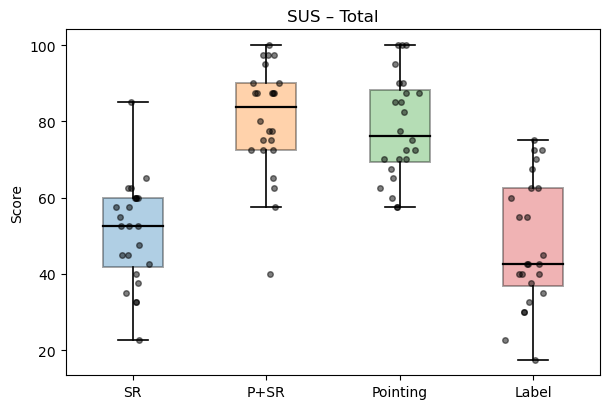

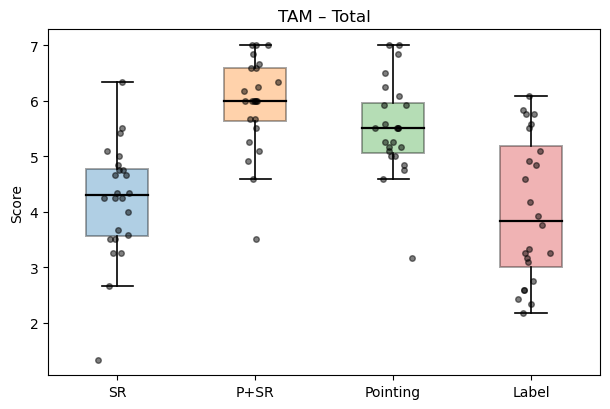

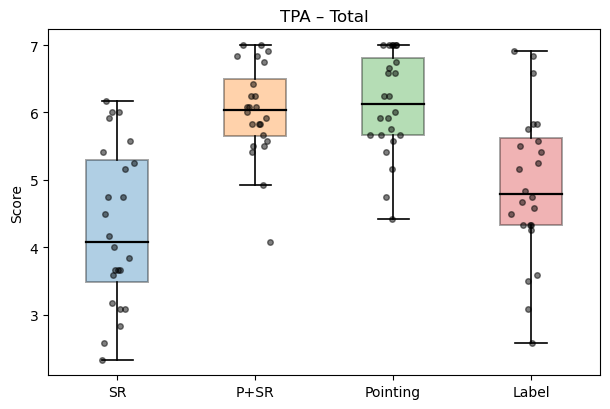

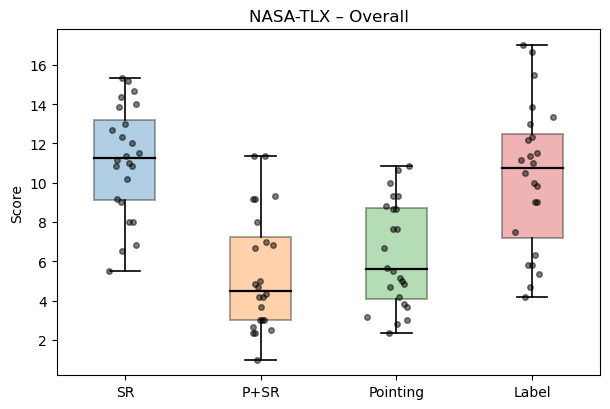

In [37]:

box_with_points(long_df, "SUS", "Total",SAVE_FIG=True)
box_with_points(long_df, "TAM", "Total",SAVE_FIG=True)
box_with_points(long_df, "TPA", "Total",SAVE_FIG=True)
box_with_points(long_df, "NASA-TLX", "Overall",SAVE_FIG=True)


In [1]:
# === Bradley–Terry をノートブックで先に計算して、scores/beta/ci95 を用意するセル ===
import os, math
import numpy as np
import pandas as pd

# 1) 入力（CSVパスを必要に応じて変更）
PREF_CSV = "./ResultData/Preference.csv"  # 例: 好み順位のCSV。手元のパスに合わせて変更

# 2) 列名（あなたの日本語ヘッダ）
COL_R1 = "1番使いやすかったもの"
COL_R2 = "2番目に使いやすかったもの"
COL_R3 = "3番目に使いやすかったもの"
COL_R4 = "4番目に使いやすかったもの"

# 3) ラベル正規化（日本語→英略称）
LABEL_MAP = {
    "空間参照だけ": "SR",
    "Pointing + 空間参照": "P+SR",
    "Pointing": "Pointing",
    "Label": "Label",
}
COND_ORDER = ["SR","P+SR","Pointing","Label"]
idx = {c:i for i,c in enumerate(COND_ORDER)}

def _pairs_from_ranking(rnk):
    out = []
    for i in range(len(rnk)):
        for j in range(i+1, len(rnk)):
            out.append((rnk[i], rnk[j]))  # 左 > 右
    return out

def _normalize(x):
    if isinstance(x, str):
        return LABEL_MAP.get(x.strip(), x.strip())
    return x

# 4) ランキング取り込み
dfp = pd.read_csv(PREF_CSV)
rankings = []
for _, r in dfp.iterrows():
    rnk = [_normalize(r.get(COL_R1)), _normalize(r.get(COL_R2)),
           _normalize(r.get(COL_R3)), _normalize(r.get(COL_R4))]
    if any(pd.isna(x) for x in rnk): 
        continue
    if len(set(rnk)) == 4 and set(rnk).issubset(set(COND_ORDER)):
        rankings.append(rnk)
if not rankings:
    raise RuntimeError("ランキングデータが空です。列名と値を確認してください。")

# 5) 勝敗エッジ作成＋診断用カウント
K = len(COND_ORDER)
counts = np.zeros((K,K), dtype=int)  # counts[w,l]: w が l に勝った回数
edges = []
for rnk in rankings:
    for (w, l) in _pairs_from_ranking(rnk):
        wi, li = idx[w], idx[l]
        counts[wi, li] += 1
        edges.append((wi, li))

# 6) ILSR + スムージング（choix）
try:
    import choix
except Exception as e:
    raise RuntimeError("choix がインストールされていません。`pip install choix` を実行してください。") from e

def fit_bt_with_smoothing(edges, max_boost=3):
    """強連結でないときに、全ペアへ両方向の擬似試合を加えて安定化"""
    base = list(edges)
    for boost in range(0, max_boost+1):
        try:
            if boost == 0:
                theta = choix.ilsr_pairwise(K, base)
            else:
                aug = list(base)
                for i in range(K):
                    for j in range(K):
                        if i == j: 
                            continue
                        aug.extend([(i, j)] * boost)  # 両方向に擬似試合
                theta = choix.ilsr_pairwise(K, aug)
            theta = np.array(theta) - np.mean(theta)  # 平均0基準化
            return theta, boost
        except Exception:
            continue
    raise RuntimeError("BT推定に失敗（スムージングしても収束せず）")

theta, used_boost = fit_bt_with_smoothing(edges, max_boost=3)

# 7) softmax score / beta / （このセルでは ci95 は省略 → None）
ex = np.exp(theta - np.max(theta))
probs = ex / ex.sum()
scores = {COND_ORDER[i]: float(probs[i]) for i in range(K)}
beta   = {COND_ORDER[i]: float(theta[i]) for i in range(K)}
ci95   = None  # ブートストラップCIが必要なら別セルで追加できます

# 8) 参考: AIC/BIC（擬似試合は尤度に含めない）
def _ll(th):
    s = 0.0
    for (w, l) in edges:
        s += math.log(1.0/(1.0 + math.exp(th[l]-th[w])))
    return s
ll = _ll(theta)
AIC = -2*ll + 2*(K-1)
BIC = -2*ll + (K-1)*math.log(len(edges))

print(f"n(valid)={len(rankings)}, AIC={AIC:.2f}, BIC={BIC:.2f}, smoothing_boost={used_boost}")
print("scores:", scores)
print("beta  :", beta)

# これで `scores` / `beta` / `ci95` が定義されました。続けてバーグラフのセルを実行してください。


n(valid)=24, AIC=78.15, BIC=87.06, smoothing_boost=1
scores: {'SR': 0.015314259571725232, 'P+SR': 0.8901897692850101, 'Pointing': 0.08006410250034714, 'Label': 0.014431868642917563}
beta  : {'SR': -1.414336985735727, 'P+SR': 2.648313285667461, 'Pointing': 0.23970621682830373, 'Label': -1.4736825167600378}


In [4]:
# === Bradley–Terry 可視化（バーグラフ + 可能ならβの誤差棒） ===
import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt

def plot_bt_results(scores: dict, beta: dict | None = None, ci95: dict | None = None,
                    order=("SR","P+SR","Pointing","Label"),
                    colors=("#89b4e5","#f4b183","#a9d18e","#f4b6b8")):
    """Bradley–Terry可視化（同じ配色を適用）"""
    labs = list(order)
    vals = [scores[k] for k in labs]

    # === softmax スコアバー ===
    plt.figure(figsize=(6.4, 4.0))
    bars = plt.bar(labs, vals, color=colors, edgecolor="black", alpha=0.9)
    for b, v in zip(bars, vals):
        plt.text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.2f}", ha="center", va="bottom")
    plt.ylim(0, 1.0)
    plt.ylabel("Preference score (softmax)")
    plt.title("Bradley–Terry: Preference (higher is better)")
    plt.tight_layout()
    plt.show()

    # === βプロット（ロジット空間） ===
    if beta is not None:
        bvals = np.array([beta[k] for k in labs], dtype=float)
        if ci95 is not None and all(k in ci95 for k in labs):
            lo = np.array([ci95[k][0] for k in labs], dtype=float)
            hi = np.array([ci95[k][1] for k in labs], dtype=float)
            yerr = np.vstack([bvals - lo, hi - bvals])
        else:
            yerr = None

        plt.figure(figsize=(6.4, 4.0))
        for i, lab in enumerate(labs):
            plt.scatter(i, bvals[i], s=60, color=colors[i], edgecolor="black", zorder=3)
            if yerr is not None:
                plt.errorbar(i, bvals[i],
                             yerr=[[yerr[0, i]], [yerr[1, i]]],
                             fmt="none", ecolor="black", capsize=4, zorder=2)
        plt.axhline(0, linestyle="--", color="gray")
        plt.xticks(range(len(labs)), labs)
        plt.ylabel("β (log-ability, mean-centered)")
        plt.title("Bradley–Terry: β estimates")
        plt.tight_layout()
        plt.show()



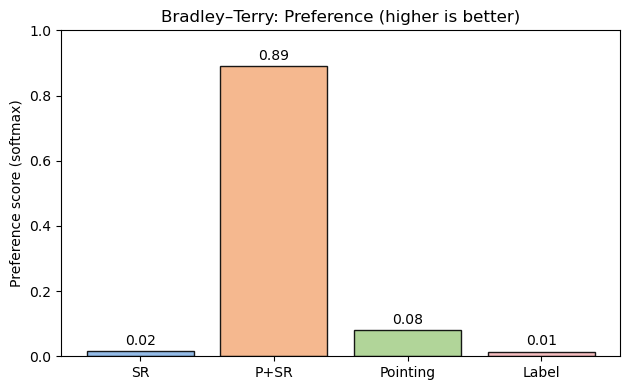

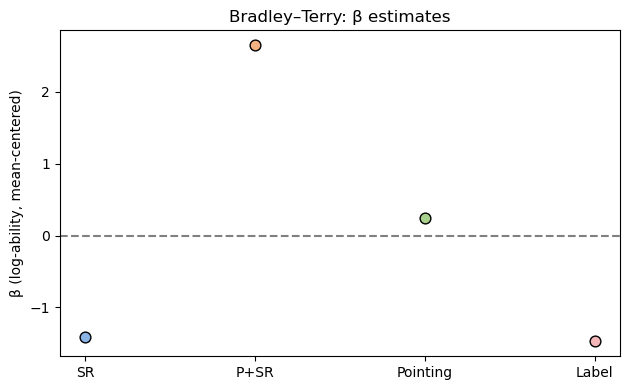

In [5]:

# ===== 実行 =====
# 既に `scores` が定義されている前提（先ほどのBT推定セルの出力）
try:
    plot_bt_results(scores=scores, beta=locals().get("beta"), ci95=locals().get("ci95"))
except NameError as e:
    raise RuntimeError("先に Bradley–Terry の推定（scores/beta/ci95）を計算してください。") from e
